In [174]:
import torch
import matplotlib.pyplot as plt

In [175]:
# 1.读取图片
img=plt.imread('duck.jpg')
print(img.shape)

(1080, 1080, 3)


In [176]:
# 2.将图片数据调整为卷积层输入特征图对应的形状
input=torch.tensor(img).permute(2,0,1).float()
print("输入特征的形状：",input.shape)

输入特征的形状： torch.Size([3, 1080, 1080])


In [177]:
# 3.定义卷积层
conv=torch.nn.Conv2d(in_channels=3,out_channels=3,kernel_size=9,stride=3,padding=0,bias=False)

In [178]:
# 4.前向传播，将卷积层运用到输入特征图上
output=conv(input)
print("输出特征的形状：",output.shape)

输出特征的形状： torch.Size([3, 358, 358])


In [179]:
# 5.定义池化层
pool=torch.nn.MaxPool2d(kernel_size=6,stride=6,padding=1)

In [180]:
# 6.前向传播，进行池化操作
output2=pool(output)
print(output2.shape)

torch.Size([3, 60, 60])


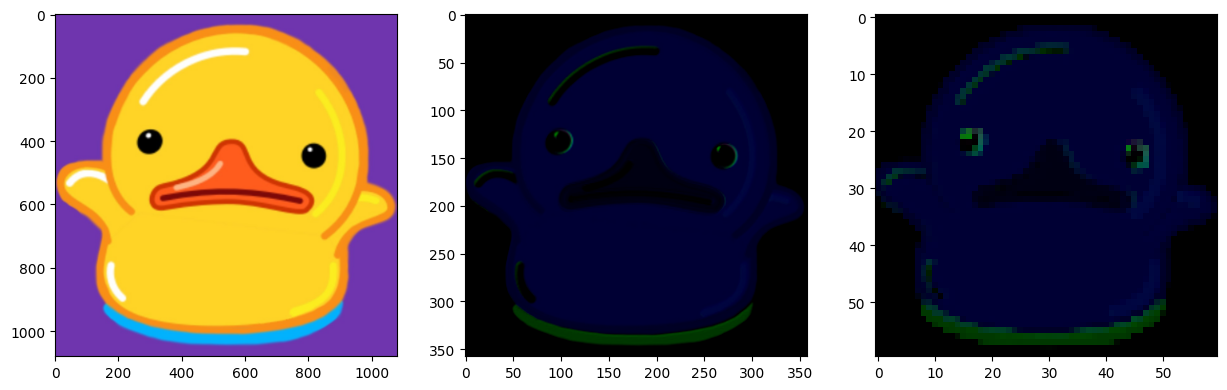

In [181]:
# 画图
output=torch.clamp(output.int(),0,255)
output=output.permute(1,2,0).detach().numpy()
output2=torch.clamp(output2.int(),0,255)
output2=output2.permute(1,2,0).detach().numpy()
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(img)
ax[1].imshow(output)
ax[2].imshow(output2)
plt.show()
# # 归一化操作
# output = output.float()
# output = (output - output.min()) / (output.max() - output.min()) * 255
# output = output.clamp(0, 255).byte()
# output = output.permute(1, 2, 0).detach().numpy()
#
# output2 = output2.float()
# output2 = (output2 - output2.min()) / (output2.max() - output2.min()) * 255
# output2 = output2.clamp(0, 255).byte()
# output2 = output2.permute(1, 2, 0).detach().numpy()
#
# fig, ax = plt.subplots(1, 3, figsize=(15, 5))
# ax[0].imshow(img)
# ax[1].imshow(output)
# ax[2].imshow(output2)
# plt.show()